In [1]:
import pandas as pd
import pyarrow.parquet as pq
import sys
import os
import numpy as np
import json
import time

sys.path.insert(0, os.path.join(os.getcwd(), 'chronoepilogi_implementation'))



In [ ]:
### Dataset reducing and cleaning
db = pd.read_parquet("full_train_dataset_rtf.parquet", engine="fastparquet")
db = db.drop(columns = "ce")


vehicles = db['vehicle_id'].unique()
n_vehicles_to_keep = int(0.2 * len(vehicles))
sampled_vehicles = np.random.choice(vehicles, size=n_vehicles_to_keep, replace=False)

db_small = db[db['vehicle_id'].isin(sampled_vehicles)].copy()
print(f"Original rows: {len(db)}, New rows: {len(db_small)}")

Original rows: 105852, New rows: 21264


In [14]:
db_small.head()

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_35,RUL,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
0,22,3.2,179550.0,4460.0,6791004.0,680.0,NaN,NaN,NaN,NaN,...,20.0,187.6,Cat0,Cat0,Cat0,Cat0,Cat0,Cat1,Cat0,Cat1
1,22,7.4,355095.0,16955.0,12882265.0,3504.0,NaN,NaN,NaN,NaN,...,64.0,183.4,Cat0,Cat0,Cat0,Cat0,Cat0,Cat1,Cat0,Cat1
2,22,10.8,452700.0,23437.0,16294157.0,5856.0,NaN,NaN,NaN,NaN,...,248.0,180.0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat1,Cat0,Cat1
3,22,12.2,483285.0,24978.0,17353810.0,6416.0,NaN,NaN,NaN,NaN,...,268.0,178.6,Cat0,Cat0,Cat0,Cat0,Cat0,Cat1,Cat0,Cat1
4,22,17.2,663660.0,37683.0,23636999.0,10664.0,NaN,NaN,NaN,NaN,...,325.0,173.6,Cat0,Cat0,Cat0,Cat0,Cat0,Cat1,Cat0,Cat1


In [11]:
db['time_step'] = pd.to_datetime(db['time_step'])

# Group by Episode and get min/max datetime
episodes = db.groupby('vehicle_id')['time_step'].agg(['min', 'max']).reset_index()
episodes.columns = ['Episode', 'start', 'end']
print(episodes)

      Episode                         start                           end
0          22 1970-01-01 00:00:00.000000003 1970-01-01 00:00:00.000000185
1          27 1970-01-01 00:00:00.000000012 1970-01-01 00:00:00.000000353
2          29 1970-01-01 00:00:00.000000020 1970-01-01 00:00:00.000000423
3          52 1970-01-01 00:00:00.000000000 1970-01-01 00:00:00.000000234
4          61 1970-01-01 00:00:00.000000004 1970-01-01 00:00:00.000000292
...       ...                           ...                           ...
2267    33462 1970-01-01 00:00:00.000000000 1970-01-01 00:00:00.000000319
2268    33465 1970-01-01 00:00:00.000000008 1970-01-01 00:00:00.000000186
2269    33467 1970-01-01 00:00:00.000000011 1970-01-01 00:00:00.000000191
2270    33472 1970-01-01 00:00:00.000000010 1970-01-01 00:00:00.000000203
2271    33528 1970-01-01 00:00:00.000000000 1970-01-01 00:00:00.000000299

[2272 rows x 3 columns]


In [9]:
import importlib
import OHE_chrono
import regression

importlib.reload(regression)
importlib.reload(OHE_chrono)

with open("results/Spec_0_lag_20.json") as f:
    select_columns = json.load(f)

In [8]:
for i, feature in enumerate(["Spec_0", "Spec_4", "Spec_7", "Spec_1", "Spec_2", "Spec_3", "Spec_6"], 1):
    for j, lag in enumerate([20],1):
        OHE_chrono.OHE_chrono(db_small, [feature], "RUL", lag, ["vehicle_id", "time_step"] )

Size of the sampled database: (21264, 118)
results saved here results/Spec_0_lag_20.json
Size of the sampled database: (21264, 117)
results saved here results/Spec_4_lag_20.json
Size of the sampled database: (21264, 124)
results saved here results/Spec_7_lag_20.json
Size of the sampled database: (21264, 137)
results saved here results/Spec_1_lag_20.json
Size of the sampled database: (21264, 127)
results saved here results/Spec_2_lag_20.json
Size of the sampled database: (21264, 119)
results saved here results/Spec_3_lag_20.json
Size of the sampled database: (21264, 124)
results saved here results/Spec_6_lag_20.json


== Train and Test set size ==
Train set:83864
Test set:21988
Initial db:105852

there is : 11 available features over :117

RUL analysis:
  Train mean: 117.61, Test mean: 120.11 cycles
  Train std: 84.21, Test std: 84.86
  Mean difference: -2.50 cycles
  Relative difference: -2.1%


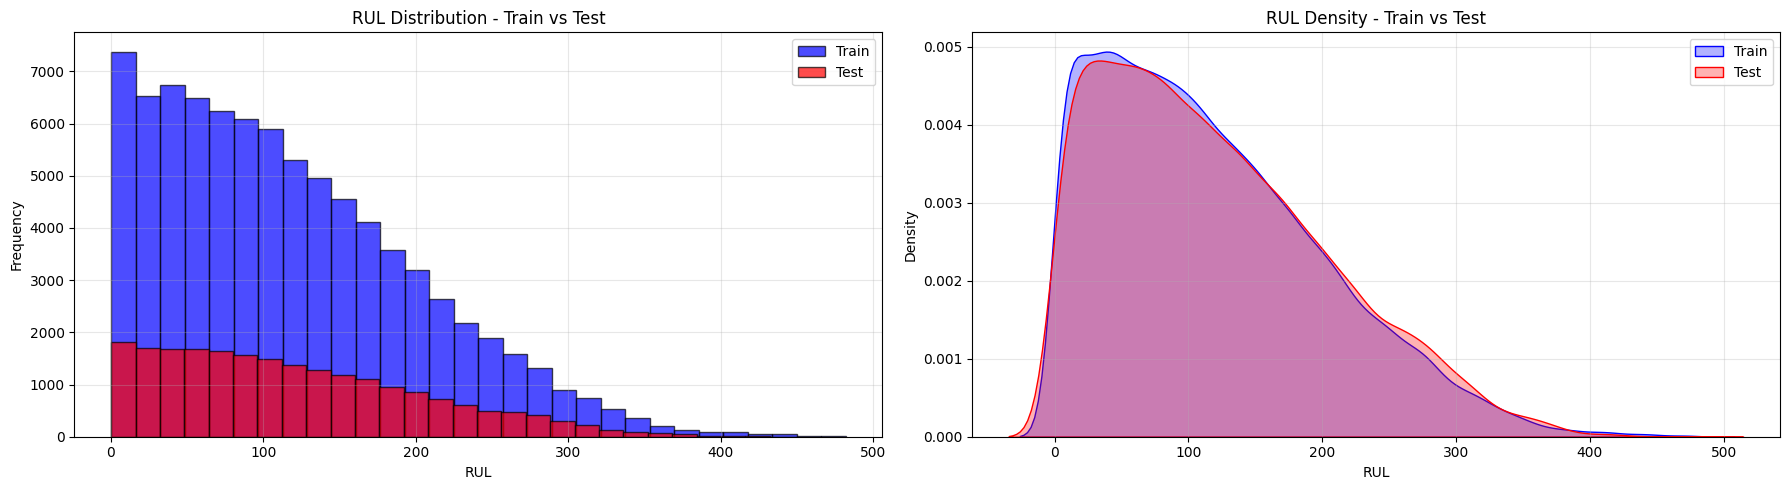


 With Xgboost
It took 3.2090578079223633 s for this method 
Mape: 52.05726447973725
R² train: 0.4454
R² (computed): 0.4454
F-statistic: 5314.2777
F p-value: 0.0000e+00

== TEST (Real performance) ==
Test R²: 0.4097


 With Gradient Boosting
It took 44.038005113601685 s for this method 
Mape: 52.12567305707509
R² train: 0.4234
R² (computed): 0.4234
F-statistic: 4953.4242
F p-value: 0.0000e+00

== TEST (Real performance) ==
Test R²: 0.4087


 With Random Forest
It took 19.303368091583252 s for this method 
Mape: 51.59590307262267
R² train: 0.4844
R² (computed): 0.4844
F-statistic: 5728.4197
F p-value: 0.0000e+00

== TEST (Real performance) ==
Test R²: 0.4180



In [12]:
model = regression.LearningModel(
    db=db,
    target='RUL',
    identifier=["vehicle_id", "time_step"],                    
    select_features=select_columns["selected set"], 
    columnToOHE="Spec_0",
    test_size=0.2
)

data = model.prepare_data()
model.analyze_data_statistics(data, plot=True)

##With xgboost
print("\n With Xgboost")
t_start = time.time()
xgb_model = model.xgboost_train(data)
print(f"It took {-t_start + time.time()} s for this method ")
model.metrics(xgb_model, data)

print("\n With Gradient Boosting")
t_start = time.time()
gb_model = model.gradient_boosting_train(data)
print(f"It took {-t_start + time.time()} s for this method ")
model.metrics(gb_model, data)

print("\n With Random Forest")
t_start = time.time()
rf_model = model.random_forest_train(data)
print(f"It took {-t_start + time.time()} s for this method ")
model.metrics(rf_model, data)



RUL analysis:
  Train mean: 117.61, Test mean: 120.11 cycles
  Train std: 84.21, Test std: 84.86
  Mean difference: -2.50 cycles
  Relative difference: -2.1%


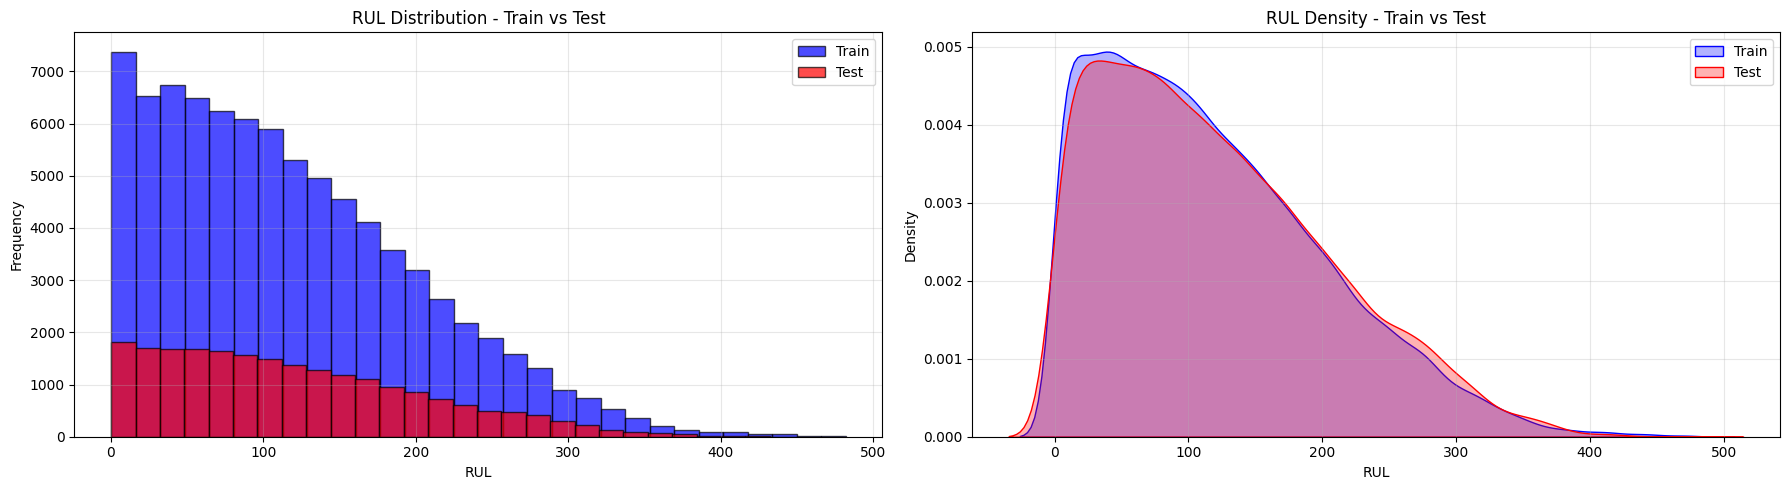


 With Xgboost
It took 19.095057249069214 s for this method 
Mape: 48.35164584934831
R² train: 0.5557
R² (computed): 0.5557
F-statistic: 475.0844
F p-value: 0.0000e+00

== TEST (Real performance) ==
Test R²: 0.4877


 With Gradient Boosting
It took 632.6771984100342 s for this method 
Mape: 48.87255281527077
R² train: 0.5112
R² (computed): 0.5112
F-statistic: 410.8605
F p-value: 0.0000e+00

== TEST (Real performance) ==
Test R²: 0.4787


 With Random Forest
It took 26.568018674850464 s for this method 
Mape: 49.75850366501166
R² train: 0.5491
R² (computed): 0.5491
F-statistic: 408.7045
F p-value: 0.0000e+00

== TEST (Real performance) ==
Test R²: 0.4606



In [13]:
model = regression.LearningModel(
    db=db,
    target='RUL',
    identifier=["vehicle_id", "time_step"],                    
    select_features=None, 
    test_size=0.2
)

data = model.prepare_data()
model.analyze_data_statistics(data, plot=True)

##With xgboost
print("\n With Xgboost")
t_start = time.time()
xgb_model = model.xgboost_train(data)
print(f"It took {-t_start + time.time()} s for this method ")
model.metrics(xgb_model, data)

print("\n With Gradient Boosting")
t_start = time.time()
gb_model = model.gradient_boosting_train(data)
print(f"It took {-t_start + time.time()} s for this method ")
model.metrics(gb_model, data)

print("\n With Random Forest")
t_start = time.time()
rf_model = model.random_forest_train(data)
print(f"It took {-t_start + time.time()} s for this method ")
model.metrics(rf_model, data)



In [ ]:
importlib.reload(regression)

model = regression.ARIMAModel(
    db=db,
    target='RUL',
    exog_features= None, 
    order=(1,0,1),                        
    test_size=0.2,
    random_state=42
)
model.fit()
preds = model.predict_test()
model.evaluate(preds)
model.plot_predictions(preds)

Train vehicles: 363 | Test vehicles: 91
Fitting model on 16941 time steps from 363 vehicles...
Model fitting completed.
Test MAE: 8.2051
Test RMSE: 33.6157


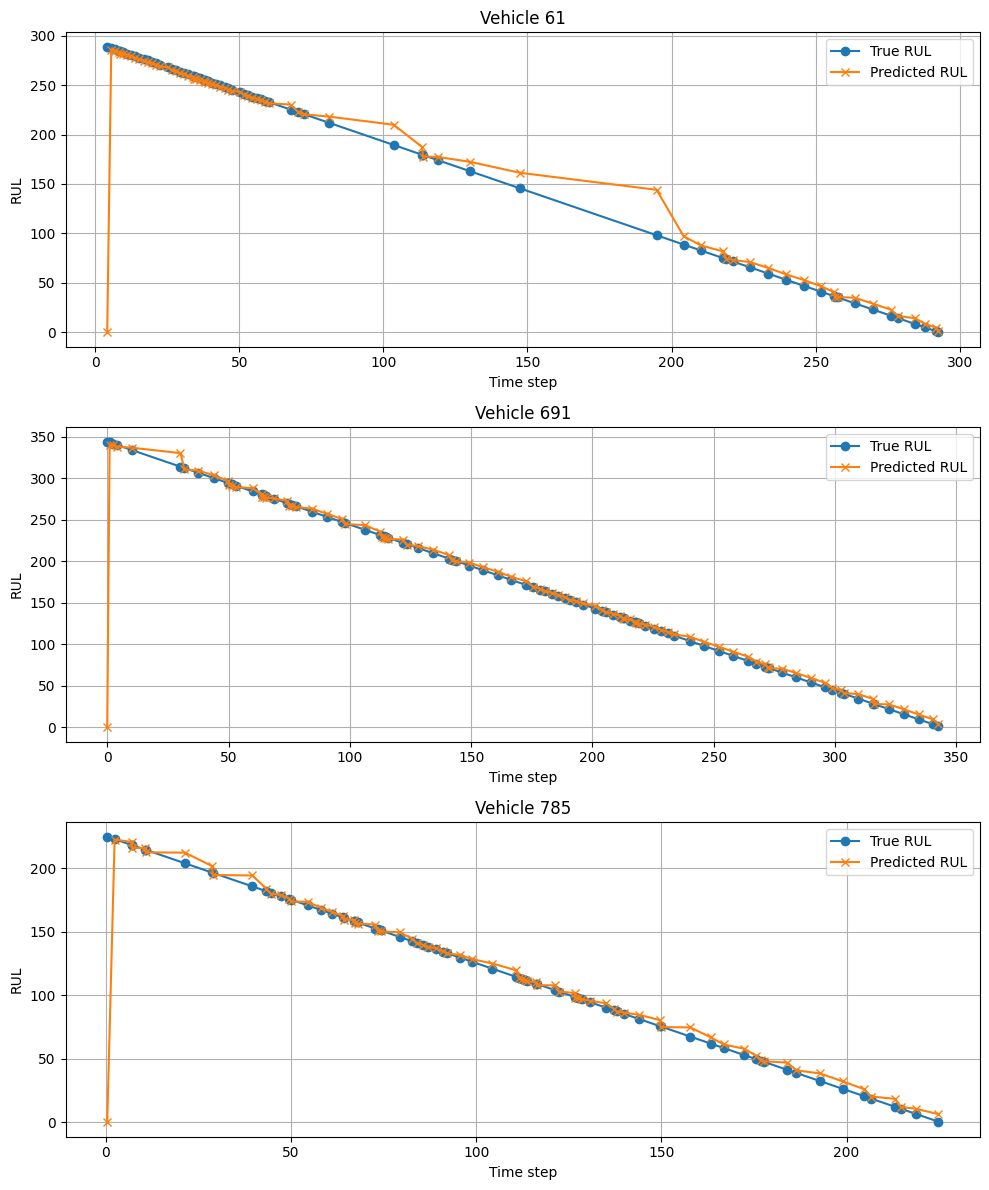

In [86]:
importlib.reload(regression)

model = regression.ARIMAModel(
    db=db_small,
    target='RUL',
)
model.fit()
preds = model.predict_test()
model.evaluate(preds)
model.plot_predictions(preds)